Install Dependencies and Dataset

In [2]:
import pandas as pd
import numpy as np
import os

In [ ]:
# os.environ['KAGGLE_USERNAME'] = 'group15aiml'
# os.environ['KAGGLE_KEY'] = 'KGAT_7d65874aaa633b5a0fcb994c3b1b837e'

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# # Install Kaggle
# !pip install -q kaggle
# # Download flickr8k
# !kaggle datasets download -d adityajn105/flickr8k
# !unzip -q flickr8k.zip -d /content/flickr8k

Dataset URL: https://www.kaggle.com/datasets/adityajn105/flickr8k
License(s): CC0-1.0
100% 1.04G/1.04G [00:09<00:00, 120MB/s]



In [7]:
!pip install -q git+https://github.com/openai/CLIP.git

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.2 MB/s eta 0:00:00


In [ ]:
# print(os.listdir("/content/flickr8k"))

# image_dir = "/content/flickr8k/Images"

# print("Number of images:", len(os.listdir(image_dir)))

['Images', 'captions.txt']
Number of images: 8091


In [ ]:
# captions = pd.read_csv("/content/flickr8k/captions.txt")

# print(captions.shape)
# captions.head()

(40455, 2)


,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...


Mount Flickr8k to Drive

In [3]:
PROJECT_DIR = "/content/drive/MyDrive/MMRetrieval"
os.makedirs(PROJECT_DIR, exist_ok=True)

In [ ]:
# !cp -r /content/flickr8k \
#       # /content/drive/MyDrive/MMRetrieval/

In [ ]:
# !ls "/content/drive/MyDrive/MMRetrieval/flickr8k"

captions.txt  Images


Divide to 4 Subsets

In [ ]:
# import clip
# import torch

# device = "cuda" if torch.cuda.is_available() else "cpu"

# model, preprocess = clip.load("ViT-B/32", device=device)

# print("Device:", device)

100%|████████████████████████████████████████| 338M/338M [00:02<00:00, 164MiB/s]


Device: cuda


In [ ]:
# captions["image"].nunique()

8091

In [ ]:
# unique_images = captions["image"].unique()

# image_subsets = np.array_split(unique_images, 4)

# for i, subset_imgs in enumerate(image_subsets):

#     subset_df = captions[
#         captions["image"].isin(subset_imgs)
#     ].reset_index(drop=True)

#     print(
#         f"Subset {i+1}:",
#         subset_df['image'].nunique(),
#         "images,",
#         len(subset_df),
#         "captions"
#     )

Subset 1: 2023 images, 10115 captions
Subset 2: 2023 images, 10115 captions
Subset 3: 2023 images, 10115 captions
Subset 4: 2022 images, 10110 captions


Save Subsets to Drive

In [ ]:
# SAVE_DIR = "/content/drive/MyDrive/Flickr8k_Subsets"

# os.makedirs(SAVE_DIR, exist_ok=True)

In [ ]:
# for i, subset_imgs in enumerate(image_subsets):

#     subset_df = captions[
#         captions["image"].isin(subset_imgs)
#     ].reset_index(drop=True)

#     save_path = f"{SAVE_DIR}/subset_{i+1}.csv"

#     subset_df.to_csv(
#         save_path,
#         index=False
#     )

#     print("Saved:", save_path)

Saved: /content/drive/MyDrive/Flickr8k_Subsets/subset_1.csv
Saved: /content/drive/MyDrive/Flickr8k_Subsets/subset_2.csv
Saved: /content/drive/MyDrive/Flickr8k_Subsets/subset_3.csv
Saved: /content/drive/MyDrive/Flickr8k_Subsets/subset_4.csv


In [ ]:
# # Save Image Lists
# import pickle

# for i, subset_imgs in enumerate(image_subsets):

#     with open(
#         f"{SAVE_DIR}/subset_{i+1}_images.pkl",
#         "wb"
#     ) as f:

#         pickle.dump(
#             list(subset_imgs),
#             f
#         )

Load Subset

In [4]:
# Load Subset 2
subset = pd.read_csv(
    "/content/drive/MyDrive/Flickr8k_Subsets/subset_2.csv"
)

print(
    subset["image"].nunique()
)

print(
    len(subset)
)

2023
10115


In [8]:
# Load CLIP
import clip
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

model, preprocess = clip.load(
    "ViT-B/32",
    device=device
)

print(device)

100%|███████████████████████████████████████| 338M/338M [00:03<00:00, 94.1MiB/s]


cuda


In [10]:
print(
    os.listdir(
        "/content/drive/MyDrive/MMRetrieval/flickr8k"
    )
)

['Images', 'captions.txt']


In [11]:
DATASET_DIR = "/content/drive/MyDrive/MMRetrieval/flickr8k"

IMAGE_DIR = f"{DATASET_DIR}/Images"

CAPTION_FILE = f"{DATASET_DIR}/captions.txt"

In [12]:
# Generate Image Embeddings
from PIL import Image
from tqdm import tqdm
import numpy as np

image_embeddings = []
image_ids = []

subset_images = subset["image"].unique()

print("Subset Images:", len(subset_images))

for img_name in tqdm(subset_images):

    img_path = f"{IMAGE_DIR}/{img_name}"

    image = preprocess(
        Image.open(img_path).convert("RGB")
    ).unsqueeze(0).to(device)

    with torch.no_grad():

        feat = model.encode_image(image)

        feat /= feat.norm(
            dim=-1,
            keepdim=True
        )

    image_embeddings.append(
        feat.cpu().numpy()[0]
    )

    image_ids.append(img_name)

image_embeddings = np.array(
    image_embeddings,
    dtype=np.float32
)

print(image_embeddings.shape)

Subset Images: 2023


100%|██████████| 2023/2023 [11:10<00:00,  3.02it/s]

(2023, 512)


In [ ]:
# os.makedirs(
#     "/content/drive/MyDrive/MMRetrieval/embeddings",
#     exist_ok=True
# )

# print(os.listdir("/content/drive/MyDrive/MMRetrieval"))

['flickr8k', 'embeddings']


In [13]:
# Save Image Embeddings
np.save(
    "/content/drive/MyDrive/MMRetrieval/embeddings/subset2_image_embeddings.npy",
    image_embeddings
)

In [14]:
# Create Caption Embeddings
caption_embeddings = []

for caption in tqdm(subset["caption"]):

    tokens = clip.tokenize(
        [caption],
        truncate=True
    ).to(device)

    with torch.no_grad():

        feat = model.encode_text(tokens)

        feat /= feat.norm(
            dim=-1,
            keepdim=True
        )

    caption_embeddings.append(
        feat.cpu().numpy()[0]
    )

caption_embeddings = np.array(
    caption_embeddings,
    dtype=np.float32
)

print(caption_embeddings.shape)

100%|██████████| 10115/10115 [01:39<00:00, 101.52it/s]

(10115, 512)


In [15]:
# Save Caption Embeddings
np.save(
    "/content/drive/MyDrive/MMRetrieval/embeddings/subset2_caption_embeddings.npy",
    caption_embeddings
)

In [17]:
# Saving Metadata
import pickle
with open(
    "/content/drive/MyDrive/MMRetrieval/embeddings/subset2_image_ids.pkl",
    "wb"
) as f:

    pickle.dump(image_ids, f)

subset.to_csv(
    "/content/drive/MyDrive/MMRetrieval/embeddings/subset2_metadata.csv",
    index=False
)

In [18]:
with open(
    "/content/drive/MyDrive/MMRetrieval/embeddings/subset2_image_ids.pkl",
    "wb"
) as f:
    pickle.dump(image_ids, f)

subset.to_csv(
    "/content/drive/MyDrive/MMRetrieval/embeddings/subset2_metadata.csv",
    index=False
)

Retreival Similarity

In [19]:
# Image to Text Retrieval
similarity_matrix = (
    image_embeddings @ caption_embeddings.T
)

print(similarity_matrix.shape)

(2023, 10115)


In [20]:
# Top 5 captions
image_idx = 0

scores = similarity_matrix[image_idx]

top5 = scores.argsort()[-5:][::-1]

for rank, cap_idx in enumerate(top5):

    print(
        f"Top-{rank+1}:",
        subset.iloc[cap_idx]["caption"]
    )

Top-1: A young man in a plaid shirts sits on the deck of a boat .
Top-2: A man in a flannel shirt and black pants sits on a ship looking out through the railing .
Top-3: A man sits by a dock looking at the water .
Top-4: A boy in a yellow shirt is looking at a bird on a wooden boardwalk
Top-5: A man sits on a dock with a bottle of water .


In [21]:
# Text to Image Retrevial
text_idx = 0

query = caption_embeddings[text_idx]

scores = query @ image_embeddings.T

top5 = scores.argsort()[-5:][::-1]

for rank, img_idx in enumerate(top5):

    print(
        f"Top-{rank+1}:",
        image_ids[img_idx]
    )

Top-1: 247617035_9f2e821534.jpg
Top-2: 269898095_d00ac7d7a4.jpg
Top-3: 3106026005_473a7b1c8c.jpg
Top-4: 2894850774_2d530040a1.jpg
Top-5: 2508249781_36e9282423.jpg


In [22]:
# Text to Text Retrevial
text_similarity = (
    caption_embeddings @ caption_embeddings.T
)

query_idx = 0

scores = text_similarity[query_idx]

scores[query_idx] = -1

top5 = scores.argsort()[-5:][::-1]

print("Query:")
print(subset.iloc[query_idx]["caption"])

print()

for rank, idx in enumerate(top5):

    print(
        f"Top-{rank+1}:",
        subset.iloc[idx]["caption"]
    )

Query:
a lone man wearing sunglasses sitting on a concrete wall

Top-1: A man in sunglasses sits on rocks .
Top-2: Man with duffel bag sitting on a concrete curb .
Top-3: Man with sunglasses sitting in shallow water .
Top-4: A man sitting on a curb in a city park .
Top-5: A man dressed like a rockstar poses in front of a brick wall .


Quantitative Evaluation

In [23]:
# Similarity Matrix
similarity_matrix = image_embeddings @ caption_embeddings.T

print(similarity_matrix.shape)

(2023, 10115)


In [24]:
print(image_embeddings.shape)
print(caption_embeddings.shape)

(2023, 512)
(10115, 512)


In [25]:
# create mappings
from collections import defaultdict

image_to_captions = defaultdict(list)

for idx, row in subset.iterrows():
    image_to_captions[row["image"]].append(idx)

print(len(image_to_captions))

2023


In [26]:
# Image to text Metrics
import numpy as np

r1 = 0
r5 = 0
r10 = 0

rr = []

for img_idx, img_name in enumerate(image_ids):

    gt = set(image_to_captions[img_name])

    ranked = np.argsort(
        similarity_matrix[img_idx]
    )[::-1]

    first_rank = None

    for rank, cap_idx in enumerate(ranked, start=1):

        if cap_idx in gt:

            first_rank = rank
            break

    rr.append(1 / first_rank)

    if first_rank <= 1:
        r1 += 1

    if first_rank <= 5:
        r5 += 1

    if first_rank <= 10:
        r10 += 1

n = len(image_ids)

print("Image → Text")

print("Recall@1 :", r1 / n)
print("Recall@5 :", r5 / n)
print("Recall@10:", r10 / n)
print("MRR      :", np.mean(rr))

Image → Text
Recall@1 : 0.6238260009886307
Recall@5 : 0.8314384577360356
Recall@10: 0.9105289174493326
MRR      : 0.717954350710483


In [27]:
# Text to Image Metrics
image_to_idx = {
    img: idx
    for idx, img in enumerate(image_ids)
}

caption_to_image = []

for _, row in subset.iterrows():

    caption_to_image.append(
        image_to_idx[row["image"]]
    )

In [28]:
text_to_image_matrix = (
    caption_embeddings @ image_embeddings.T
)

print(text_to_image_matrix.shape)

(10115, 2023)


In [29]:
r1 = 0
r5 = 0
r10 = 0

rr = []

for cap_idx in range(len(caption_to_image)):

    gt_img = caption_to_image[cap_idx]

    ranked = np.argsort(
        text_to_image_matrix[cap_idx]
    )[::-1]

    rank = (
        np.where(
            ranked == gt_img
        )[0][0]
        + 1
    )

    rr.append(1 / rank)

    if rank <= 1:
        r1 += 1

    if rank <= 5:
        r5 += 1

    if rank <= 10:
        r10 += 1

n = len(caption_to_image)

print("Text → Image")

print("Recall@1 :", r1 / n)
print("Recall@5 :", r5 / n)
print("Recall@10:", r10 / n)
print("MRR      :", np.mean(rr))

Text → Image
Recall@1 : 0.44043499752842313
Recall@5 : 0.7022244191794365
Recall@10: 0.8
MRR      : 0.5607236566179119


Qualitative

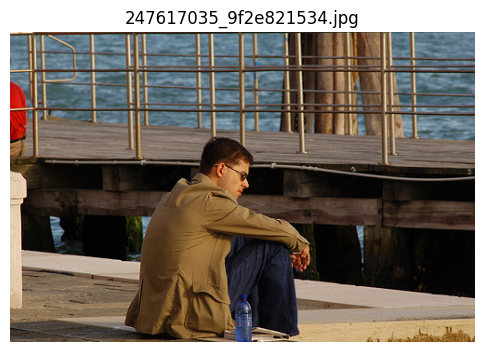

GROUND TRUTH CAPTIONS

- a lone man wearing sunglasses sitting on a concrete wall
- A man sits by a dock looking at the water .
- A man sits on a dock with a bottle of water .
- Man sitting by himself on a pier with a bottle of water .
- The man in the brown jacket is sitting on the ground by the jetty .

TOP 5 RETRIEVED CAPTIONS

1. A young man in a plaid shirts sits on the deck of a boat .
2. A man in a flannel shirt and black pants sits on a ship looking out through the railing .
3. A man sits by a dock looking at the water .
4. A boy in a yellow shirt is looking at a bird on a wooden boardwalk
5. A man sits on a dock with a bottle of water .


In [31]:
# image to text
from PIL import Image
import matplotlib.pyplot as plt

image_idx = 0

img_name = image_ids[image_idx]
img_path = f"{IMAGE_DIR}/{img_name}"

# Display image
img = Image.open(img_path)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")
plt.title(img_name)
plt.show()

# Ground Truth
print("GROUND TRUTH CAPTIONS\n")

for idx in image_to_captions[img_name]:
    print("-", subset.iloc[idx]["caption"])

# Retrieved captions
scores = similarity_matrix[image_idx]

top5 = scores.argsort()[-5:][::-1]

print("\nTOP 5 RETRIEVED CAPTIONS\n")

for rank, cap_idx in enumerate(top5):

    print(
        f"{rank+1}.",
        subset.iloc[cap_idx]["caption"]
    )

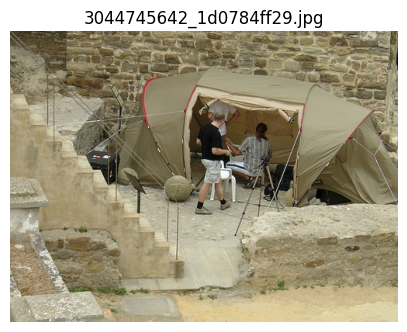

Top 5 Captions:
1. Men in a khaki-colored tent outside in a rundown area .
2. Two people are in a tent near a brick wall .
3. Two people in a tent near a rock wall .
4. At the bottom of a set of stairs , there are two men and a tent .
5. People in a tent shelter near the bottom of stairs .




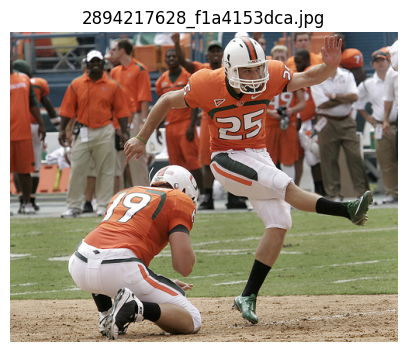

Top 5 Captions:
1. A holder and kicker for a football team dressed in orange , white and black play while onlookers behind them watch .
2. Two young men on the same football team are wearing orange and white uniforms and playing on an outside field while coaches and other players watch .
3. The football player wearing a white helmet and orange chairs swing his leg while the player next to him kneels .
4. football players wearing orange uniforms are tackling a player in a white uniform
5. Two football players , one in an orange jersey and one in a white jersey , play on the field .




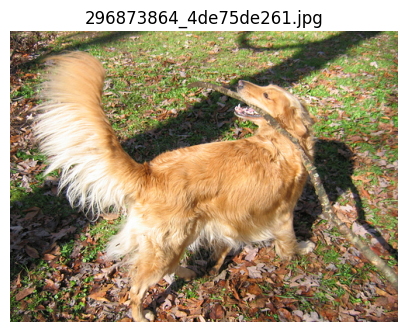

Top 5 Captions:
1. A short-haired brown dog is snapping at a long green strip .
2. A brown and white dog moving forward with two forelegs in the air and two hind legs on the ground .
3. A brown dog is running along a grassy stretch divided by strings .
4. A golden retriever running on short grass wearing an orange outfit .
5. A brown skinny dog is jumping over a tuft of grass on a dirt pathway .




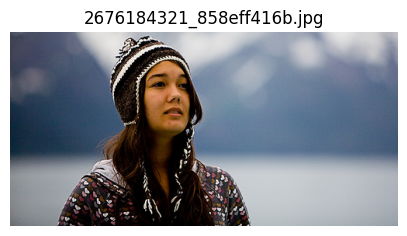

Top 5 Captions:
1. A young woman is outside in the snow wearing a hat .
2. A teenage girl is wearing a brown hat and a jacket with hearts on .
3. The girl stands outside in the cold wearing a warm hat and looking off into the distance .
4. A smiling young woman in a tourquoise shirt and bandanna poses at table outdoors .
5. A girl wearing a jacket and scarf is playing on the beach .




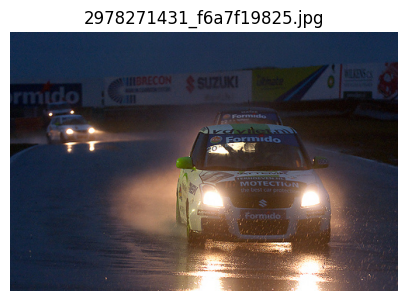

Top 5 Captions:
1. A racing car is driving around a wet track with its headlights on .
2. A sponsored race car is driving with lights on a wet raceway .
3. A white race car makes a splash through a wet track .
4. A race car drives along a track in the rain
5. A small race car with advertising is driving on a rainy track .




In [34]:
# image to text -> Random 5 images
import random

sample_images = random.sample(
    range(len(image_ids)),
    5
)

for image_idx in sample_images:

    img_name = image_ids[image_idx]

    img = Image.open(
        f"{IMAGE_DIR}/{img_name}"
    )

    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.axis("off")
    plt.title(img_name)
    plt.show()

    scores = similarity_matrix[image_idx]

    top5 = scores.argsort()[-5:][::-1]

    print("Top 5 Captions:")

    for rank, cap_idx in enumerate(top5):

        print(
            f"{rank+1}.",
            subset.iloc[cap_idx]["caption"]
        )

    print("\n" + "="*80 + "\n")

QUERY:
a lone man wearing sunglasses sitting on a concrete wall


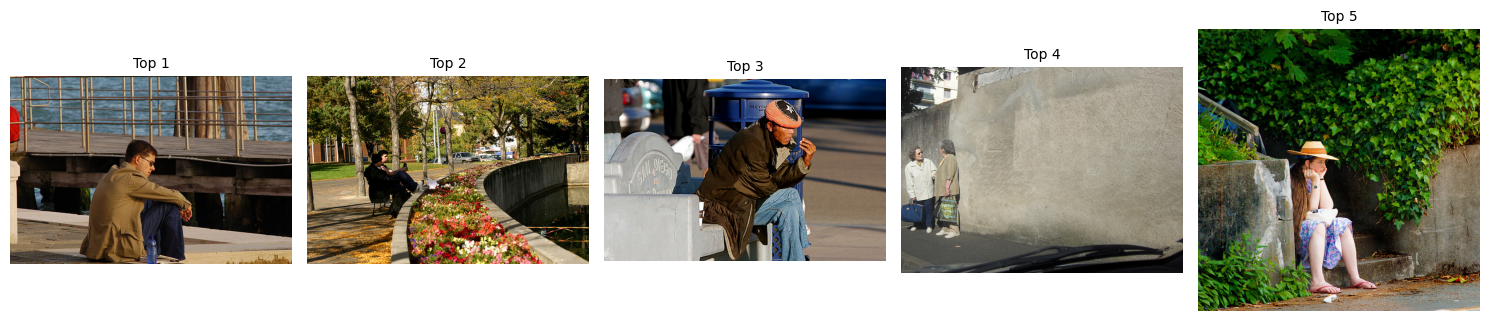

In [36]:
# text to image
caption_idx = 0

query_caption = subset.iloc[
    caption_idx
]["caption"]

print("QUERY:")
print(query_caption)

scores = text_to_image_matrix[
    caption_idx
]

top5 = scores.argsort()[-5:][::-1]

plt.figure(figsize=(15,4))

for i, img_idx in enumerate(top5):

    img_name = image_ids[img_idx]

    img = Image.open(
        f"{IMAGE_DIR}/{img_name}"
    )

    plt.subplot(1,5,i+1)

    plt.imshow(img)
    plt.axis("off")

    plt.title(
        f"Top {i+1}",
        fontsize=10
    )

plt.tight_layout()
plt.show()

In [38]:
# Text to Image -> Random 5 texts
import random

sample_caps = random.sample(
    range(len(subset)),
    5
)

for caption_idx in sample_caps:

    query_caption = subset.iloc[
        caption_idx
    ]["caption"]

    print("\nQUERY:")
    print(query_caption)

    scores = text_to_image_matrix[
        caption_idx
    ]

    top5 = scores.argsort()[-5:][::-1]

    plt.figure(figsize=(15,4))

    for i, img_idx in enumerate(top5):

        img_name = image_ids[img_idx]

        img = Image.open(
            f"{IMAGE_DIR}/{img_name}"
        )

        plt.subplot(1,5,i+1)

        plt.imshow(img)
        plt.axis("off")

        plt.title(
            f"Top {i+1}",
            fontsize=10
        )

    plt.tight_layout()
    plt.show()

    print("\n" + "="*100 + "\n")

Output hidden; open in https://colab.research.google.com to view.

In [39]:
#Text to text
query_idx = 0

scores = text_similarity[
    query_idx
].copy()

scores[query_idx] = -1

top5 = scores.argsort()[-5:][::-1]

print("QUERY:\n")
print(subset.iloc[query_idx]["caption"])

print("\nTOP 5 RETRIEVED:\n")

for rank, idx in enumerate(top5):

    print(
        f"{rank+1}.",
        subset.iloc[idx]["caption"]
    )

QUERY:

a lone man wearing sunglasses sitting on a concrete wall

TOP 5 RETRIEVED:

1. A man in sunglasses sits on rocks .
2. Man with duffel bag sitting on a concrete curb .
3. Man with sunglasses sitting in shallow water .
4. A man sitting on a curb in a city park .
5. A man dressed like a rockstar poses in front of a brick wall .
